Dataset shape: (121, 22)
Columns: ['incident_date', 'year', 'month', 'season', 'age_at_incident_years', 'construction_decade', 'construction_year', 'release_tons', 'damage_cost_usd', 'detection_method', 'detection_success', 'response_time_minutes', 'equipment_failed', 'terrain_type', 'state', 'latitude', 'longitude', 'pipeline_diameter_inches', 'operating_pressure_psi', 'soil_type', 'corrosion_inhibitor', 'cathodic_protection']

GENERATING BEAUTIFUL VISUALIZATIONS

1. Creating Correlation Heatmap...


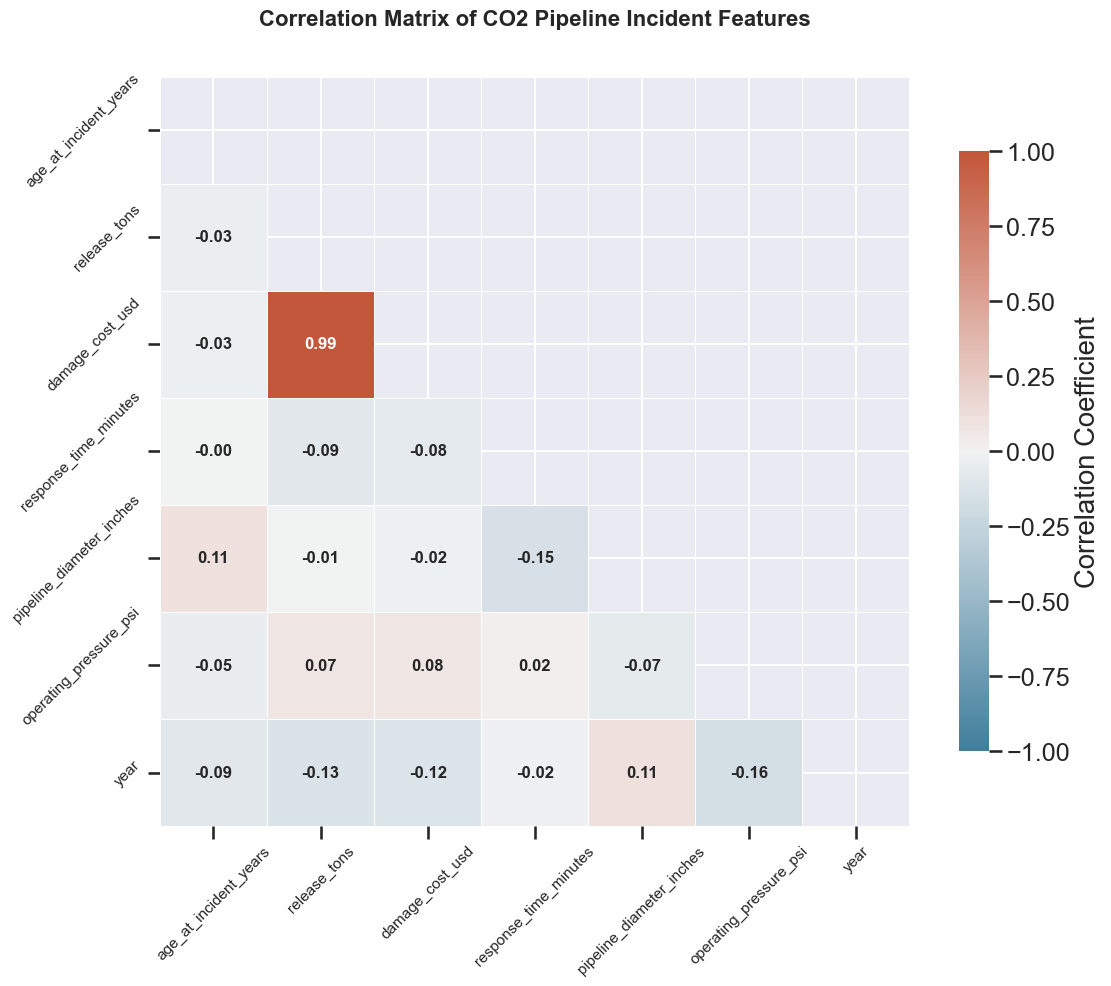


KEY CORRELATION INSIGHTS
Release volume vs Damage: 0.992
Age vs Release volume: -0.033
Response time vs Damage: -0.077

2. Creating Geographic Heatmap...


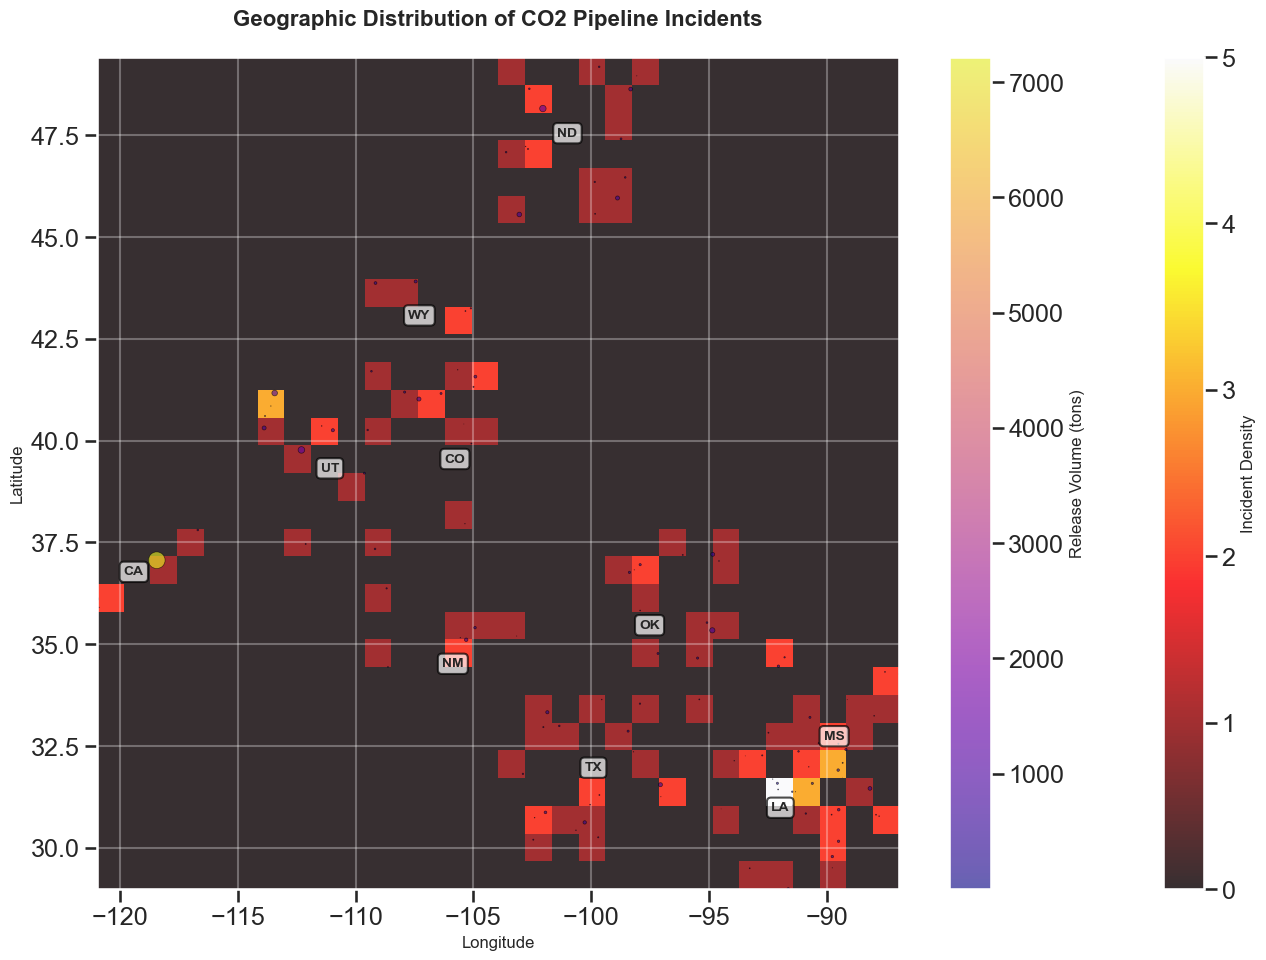


3. Creating Equipment-Terrain Heatmap...


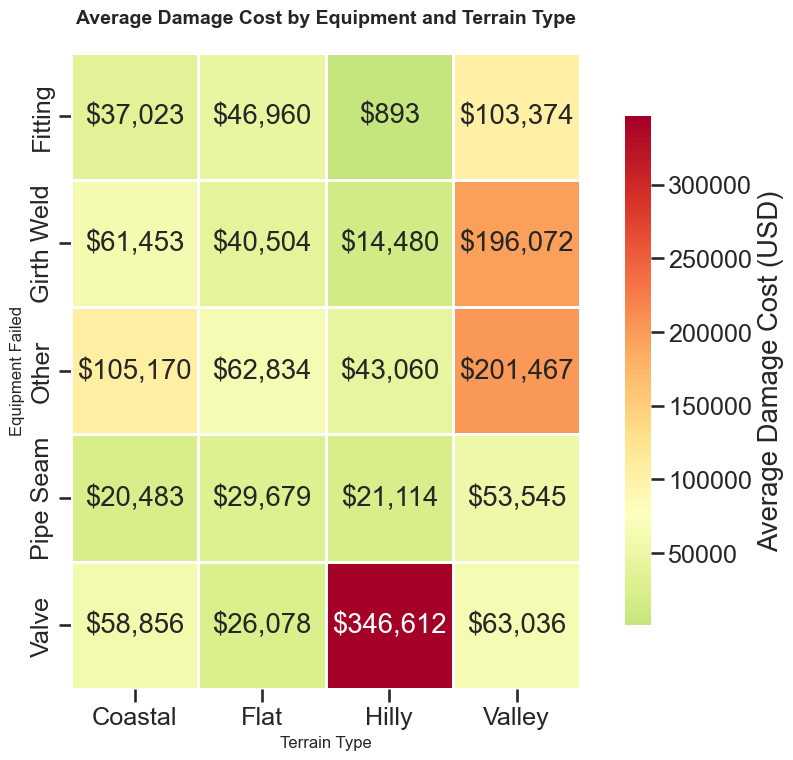


EQUIPMENT-TERRAIN INSIGHTS
Highest damage combination: Valve on Hilly terrain ($346,612)

4. Creating Seasonal Heatmap...


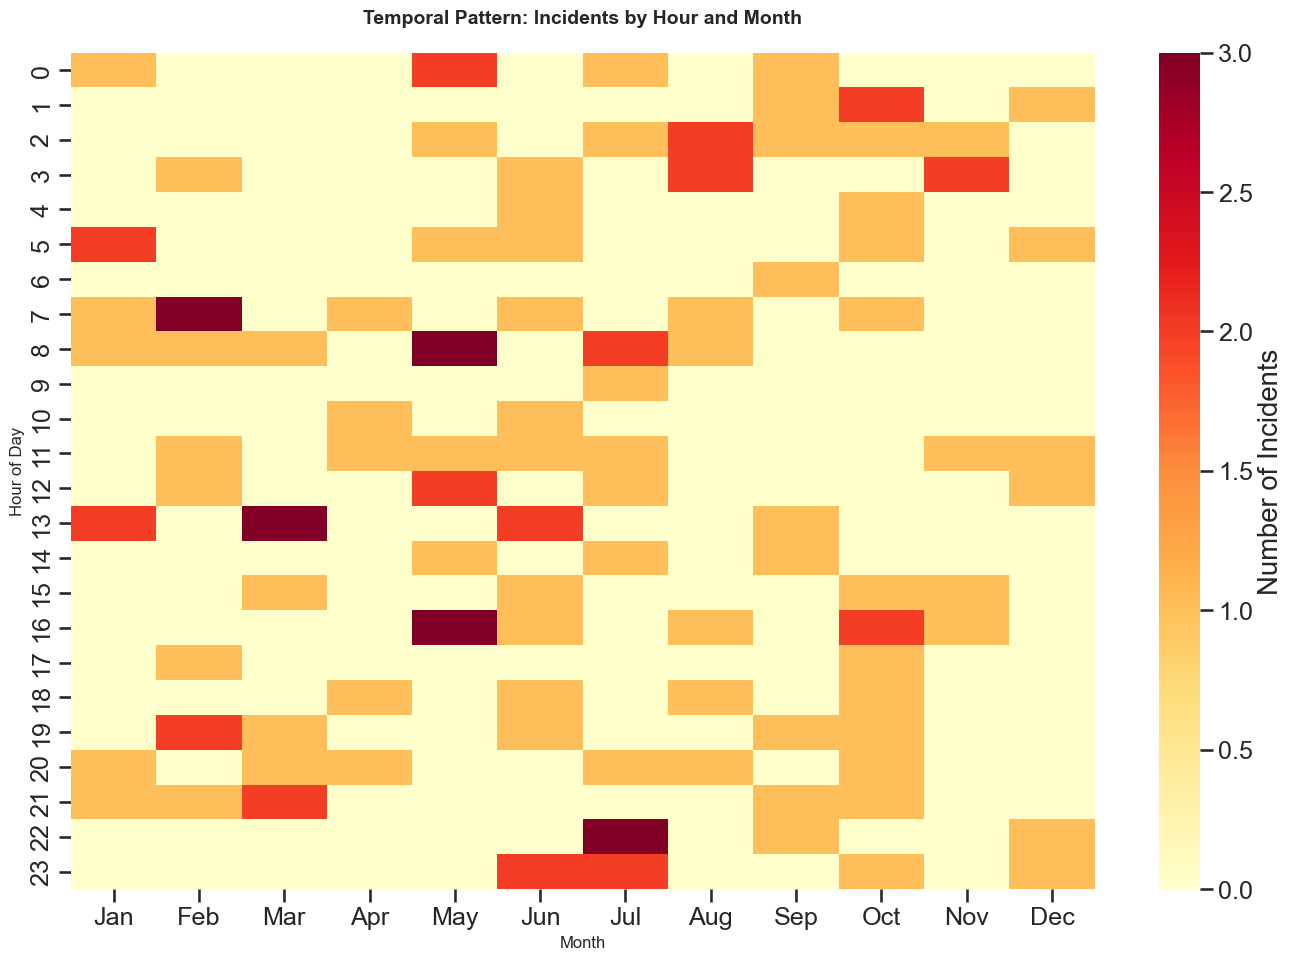


SEASONAL PATTERN ANALYSIS
  Summer: 37 incidents (30.6%)
  Fall: 30 incidents (24.8%)
  Spring: 28 incidents (23.1%)
  Winter: 26 incidents (21.5%)

5. Creating Feature Clustermap...


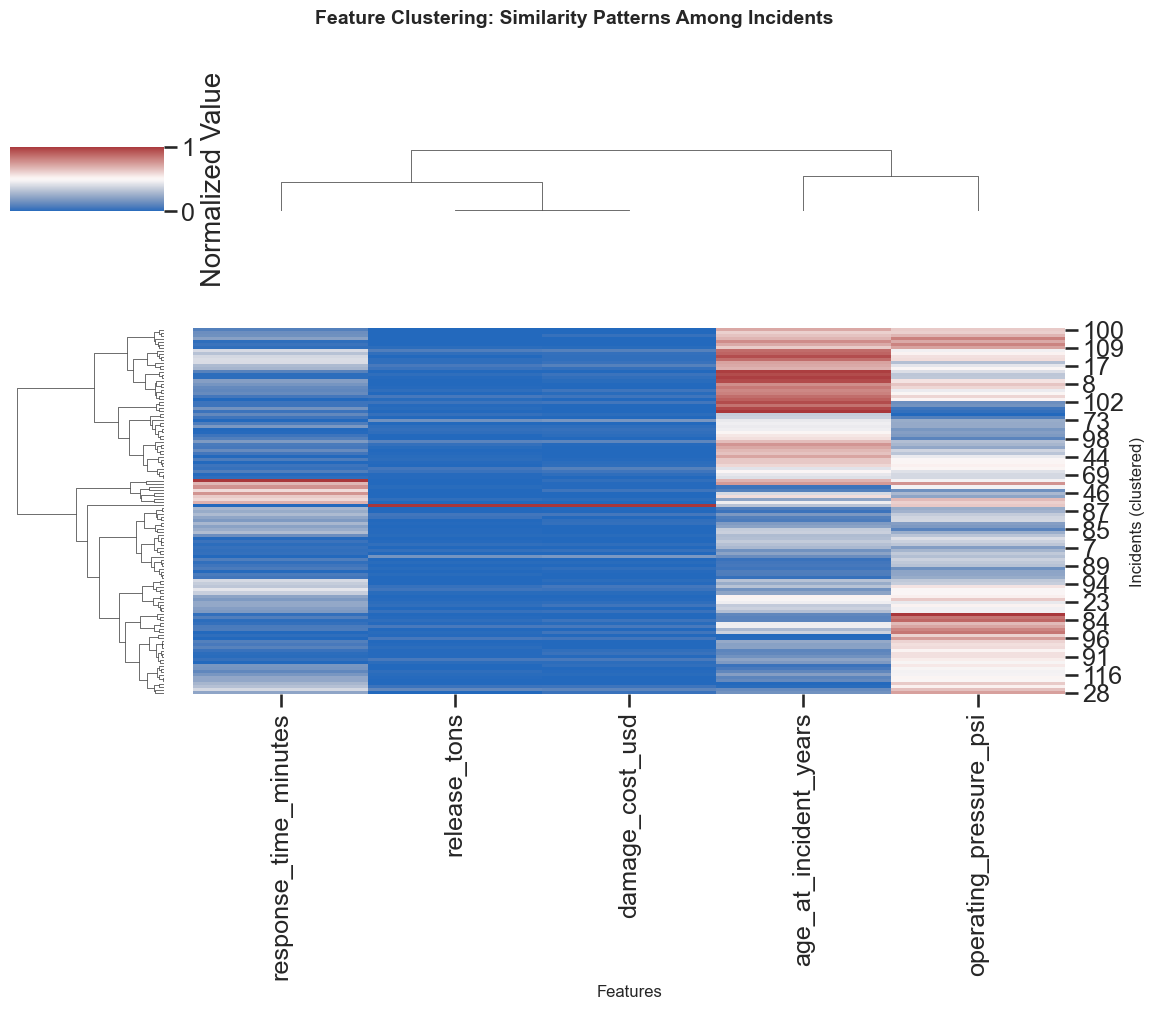


6. Creating Pairplot Matrix...


<Figure size 1400x1200 with 0 Axes>

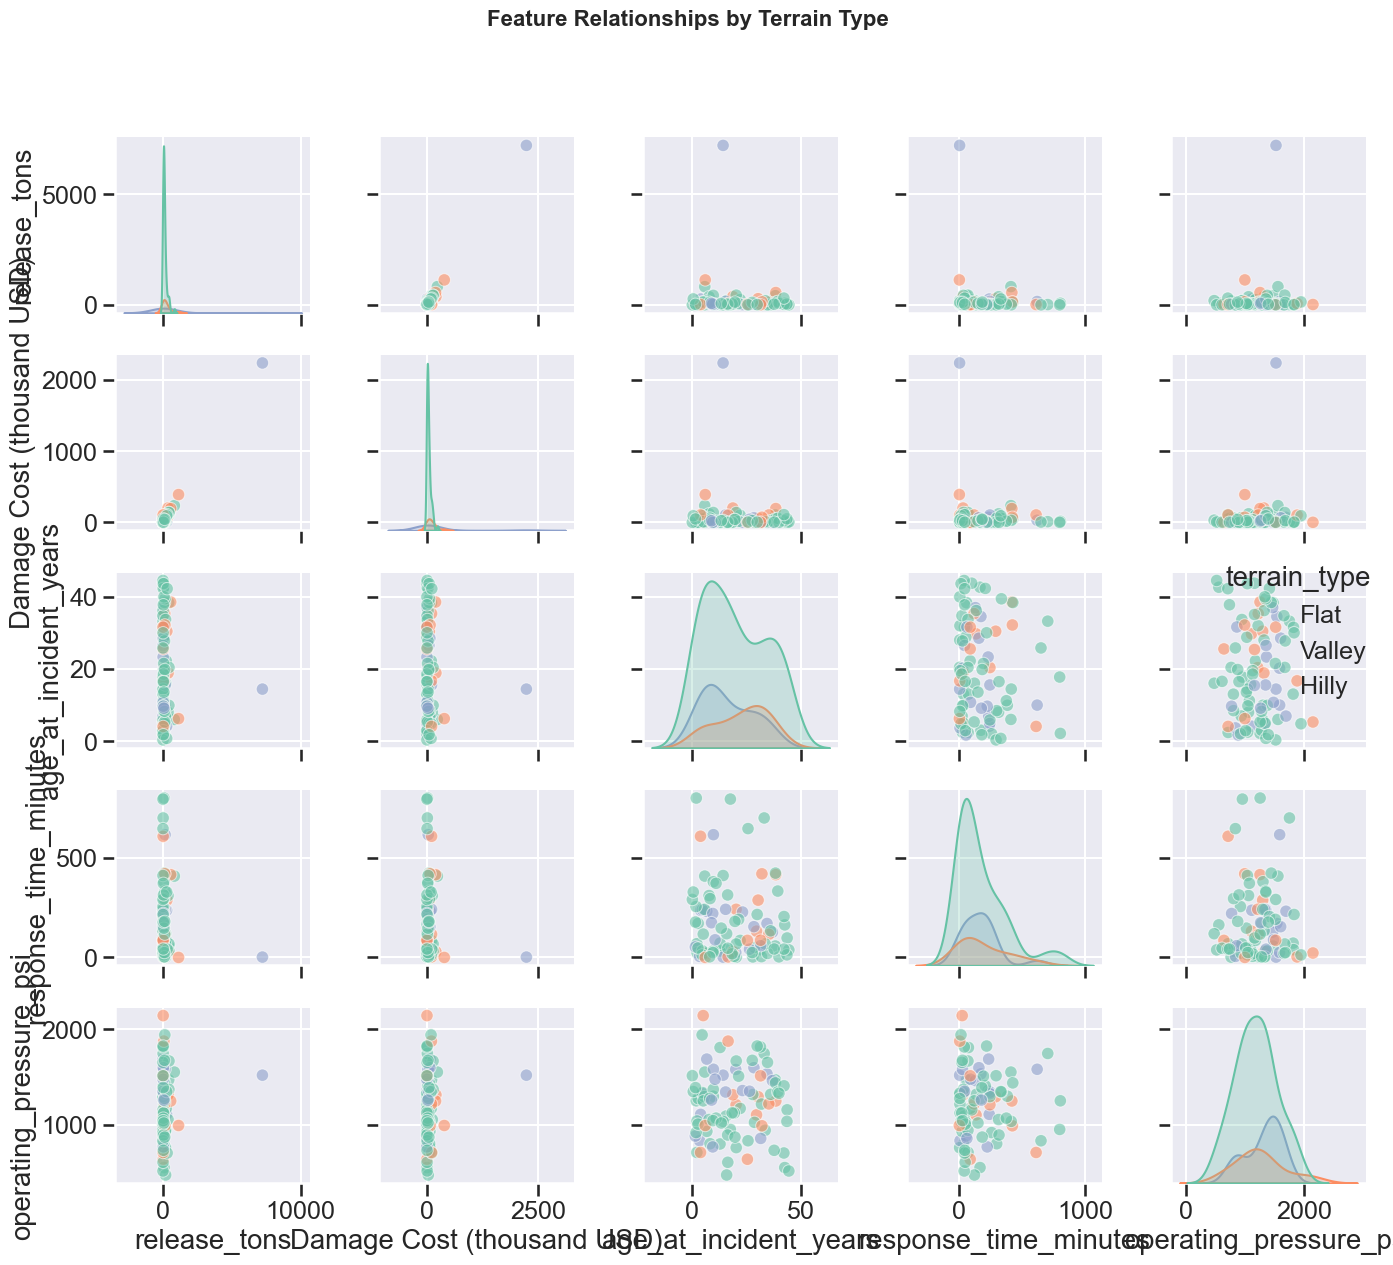


7. Creating Risk Matrix Heatmap...


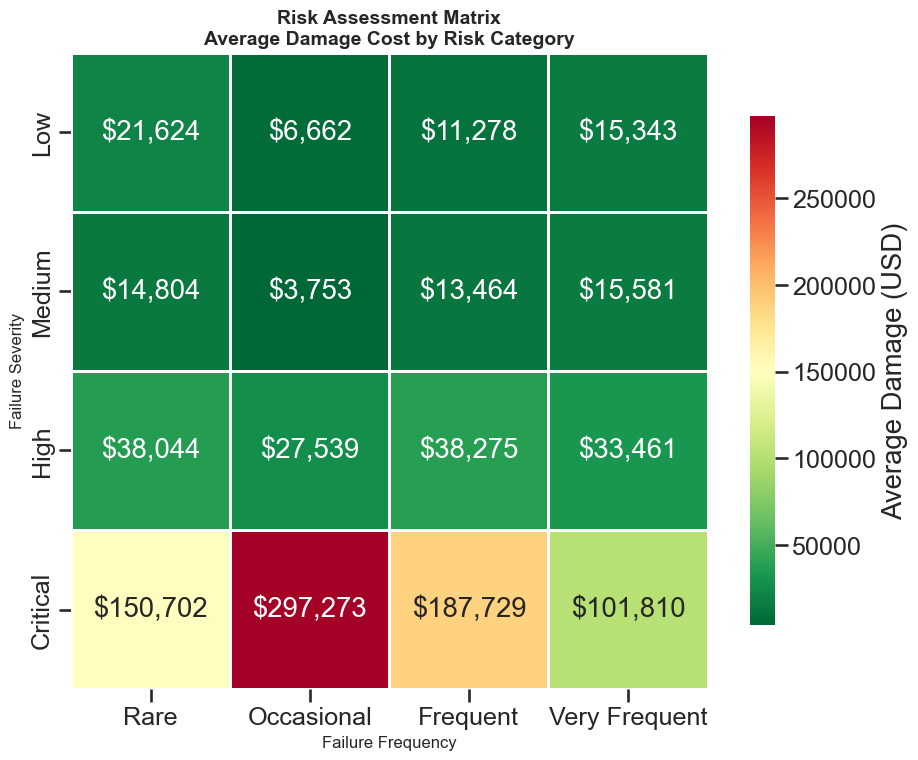


RISK MATRIX INSIGHTS
Highest risk cell: Severity=Critical, Frequency=Occasional ($297,273)

8. Creating Release Volume Distribution Plots...


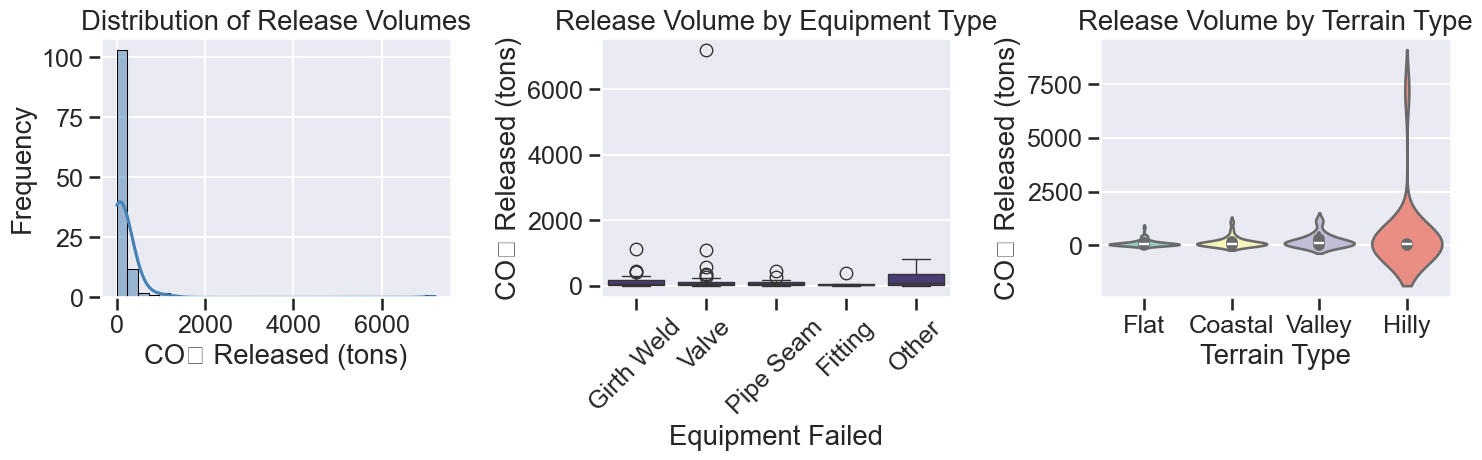


RELEASE VOLUME STATISTICS
Mean release: 179 tons
Median release: 49 tons
Max release: 7216 tons
75th percentile: 135 tons

9. Creating Detection Performance Plot...


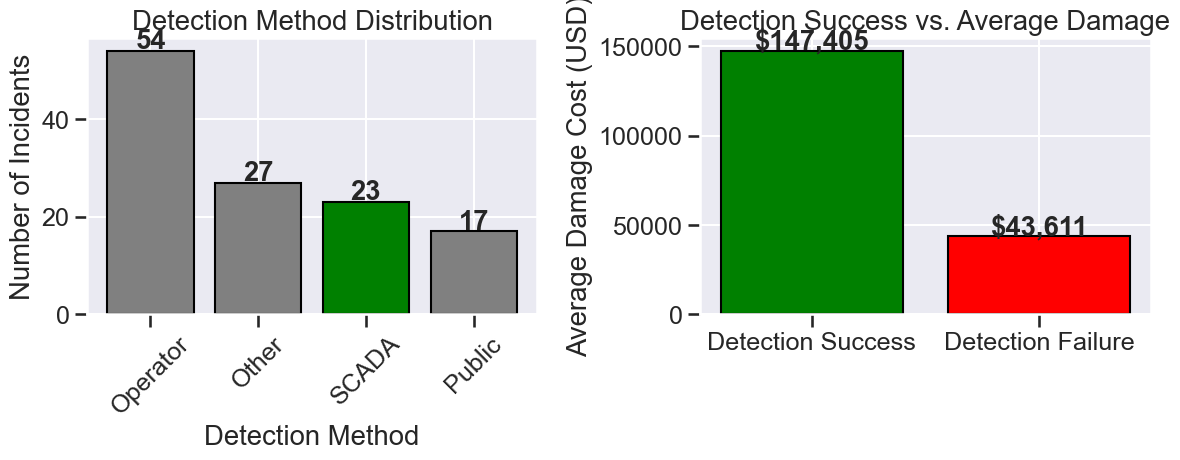


DETECTION SYSTEM PERFORMANCE
SCADA detection rate: 19.0%
Public reporting rate: 14.0%

10. Creating Interactive Dashboard...
Saved: interactive_3d_scatter.html
Saved: interactive_sunburst.html
Saved: interactive_parallel_coords.html
Saved: interactive_timeline.html

✅ All visualizations generated successfully!
   Saved files:
   - correlation_heatmap.png
   - geographic_heatmap.png
   - equipment_terrain_heatmap.png
   - seasonal_heatmap.png
   - feature_clustermap.png
   - pairplot_matrix.png
   - risk_matrix_heatmap.png
   - release_distribution.png
   - detection_performance.png
   - interactive_3d_scatter.html
   - interactive_sunburst.html
   - interactive_parallel_coords.html
   - interactive_timeline.html

📊 Enhanced dataset exported to 'co2_pipeline_enhanced_analysis.csv'

📈 SUMMARY STATISTICS:
       release_tons  damage_cost_usd  age_at_incident_years  \
count    121.000000     1.210000e+02             121.000000   
mean     178.505271     6.334057e+04              18.713020

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for professional visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
sns.set_context("talk", font_scale=1.1)

# For interactive visualizations (optional)
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly not available. Install with: pip install plotly")

# ============================================
# STEP 1: GENERATE ENHANCED SYNTHETIC DATASET
# ============================================

np.random.seed(42)

n_incidents = 121
total_release = 19717
total_damage = 6.96e6

def generate_enhanced_phmsa_data():
    """Generate realistic synthetic PHMSA CO2 pipeline incident data with additional features"""
    
    start_date = datetime(1994, 1, 1)
    end_date = datetime(2024, 12, 31)
    date_range_days = (end_date - start_date).days
    
    dates = [start_date + timedelta(days=np.random.randint(0, date_range_days)) 
             for _ in range(n_incidents)]
    dates.sort()
    
    # Age-based failure rates
    ages_years = []
    for _ in range(n_incidents):
        r = np.random.random()
        if r < 0.35:
            age = np.random.uniform(0, 10)
        elif r < 0.65:
            age = np.random.uniform(10, 25)
        else:
            age = np.random.uniform(25, 45)
        ages_years.append(age)
    
    current_year = 2024
    construction_years = [current_year - int(age) for age in ages_years]
    construction_decades = [f"{int(str(year)[2])}0s" if year >= 1970 else "1970s" for year in construction_years]
    
    # Release volume
    release_tons = np.random.lognormal(mean=3.5, sigma=1.5, size=n_incidents)
    release_tons = release_tons / release_tons.sum() * total_release
    
    # Damage cost
    damage_cost = release_tons * 50 + np.random.normal(0, 5000, n_incidents)
    damage_cost = np.maximum(damage_cost, 100)
    damage_cost = damage_cost / damage_cost.sum() * total_damage
    
    # Detection method
    detection_method = np.random.choice(
        ['SCADA', 'Public', 'Operator', 'Other'],
        size=n_incidents,
        p=[0.203, 0.170, 0.400, 0.227]
    )
    detection_success = detection_method == 'SCADA'
    
    # Equipment type
    equipment = np.random.choice(
        ['Valve', 'Girth Weld', 'Pipe Seam', 'Fitting', 'Other'],
        size=n_incidents,
        p=[0.35, 0.25, 0.20, 0.10, 0.10]
    )
    
    # Terrain type
    terrain = np.random.choice(
        ['Flat', 'Hilly', 'Coastal', 'Valley'],
        size=n_incidents,
        p=[0.55, 0.15, 0.20, 0.10]
    )
    terrain_multiplier = {'Flat': 0.8, 'Hilly': 1.4, 'Coastal': 1.0, 'Valley': 1.6}
    release_tons = release_tons * [terrain_multiplier[t] for t in terrain]
    damage_cost = damage_cost * [terrain_multiplier[t] for t in terrain]
    
    # Location
    states = np.random.choice(
        ['MS', 'TX', 'LA', 'ND', 'WY', 'CA', 'OK', 'NM', 'CO', 'UT'],
        size=n_incidents,
        p=[0.12, 0.25, 0.15, 0.08, 0.08, 0.05, 0.10, 0.07, 0.05, 0.05]
    )
    
    # Add latitude and longitude for heatmaps
    state_coords = {
        'MS': (32.7416, -89.6787), 'TX': (31.9686, -99.9018), 'LA': (30.9843, -91.9623),
        'ND': (47.5515, -101.0020), 'WY': (43.0760, -107.2903), 'CA': (36.7783, -119.4179),
        'OK': (35.4676, -97.5164), 'NM': (34.5199, -105.8701), 'CO': (39.5501, -105.7821),
        'UT': (39.3210, -111.0937)
    }
    
    latitudes = []
    longitudes = []
    for state in states:
        lat, lon = state_coords[state]
        latitudes.append(lat + np.random.uniform(-2, 2))
        longitudes.append(lon + np.random.uniform(-3, 3))
    
    # Additional features
    pipeline_diameter = np.random.choice([6, 8, 10, 12, 16, 20, 24], size=n_incidents, 
                                          p=[0.15, 0.20, 0.25, 0.20, 0.10, 0.05, 0.05])
    operating_pressure = np.random.normal(1200, 300, n_incidents)
    operating_pressure = np.clip(operating_pressure, 400, 2500)
    
    soil_type = np.random.choice(['Clay', 'Sand', 'Rock', 'Loam'], size=n_incidents, 
                                  p=[0.3, 0.25, 0.25, 0.2])
    
    corrosion_inhibitor = np.random.choice([True, False], size=n_incidents, p=[0.7, 0.3])
    
    cathodic_protection = np.random.choice(['Yes', 'No', 'Partial'], size=n_incidents, 
                                            p=[0.6, 0.2, 0.2])
    
    # Response time (minutes) - correlated with detection method
    response_time = np.where(detection_success, 
                            np.random.exponential(30, n_incidents),
                            np.random.exponential(180, n_incidents))
    
    df = pd.DataFrame({
        'incident_date': dates,
        'year': [d.year for d in dates],
        'month': [d.month for d in dates],
        'season': [get_season(d) for d in dates],
        'age_at_incident_years': ages_years,
        'construction_decade': construction_decades,
        'construction_year': construction_years,
        'release_tons': release_tons,
        'damage_cost_usd': damage_cost,
        'detection_method': detection_method,
        'detection_success': detection_success,
        'response_time_minutes': response_time,
        'equipment_failed': equipment,
        'terrain_type': terrain,
        'state': states,
        'latitude': latitudes,
        'longitude': longitudes,
        'pipeline_diameter_inches': pipeline_diameter,
        'operating_pressure_psi': operating_pressure,
        'soil_type': soil_type,
        'corrosion_inhibitor': corrosion_inhibitor,
        'cathodic_protection': cathodic_protection
    })
    
    return df

def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df = generate_enhanced_phmsa_data()
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# ============================================
# STEP 2: VISUALIZATIONS 
# ============================================

class CO2VisualizationAnalyzer:
    def __init__(self, df):
        self.df = df
        
    def correlation_heatmap(self):
        """Create a beautiful correlation matrix heatmap"""
        # Select numeric columns for correlation
        numeric_cols = ['age_at_incident_years', 'release_tons', 'damage_cost_usd', 
                       'response_time_minutes', 'pipeline_diameter_inches', 
                       'operating_pressure_psi', 'year']
        
        corr_matrix = self.df[numeric_cols].corr()
        
        # Create mask for upper triangle
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        
        # Set up the matplotlib figure
        fig, ax = plt.subplots(figsize=(12, 10))
        
        # Generate custom colormap
        cmap = sns.diverging_palette(230, 20, as_cmap=True)
        
        # Draw the heatmap
        sns.heatmap(corr_matrix, 
                    mask=mask,
                    cmap=cmap,
                    vmax=1,
                    vmin=-1,
                    center=0,
                    square=True,
                    linewidths=0.5,
                    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
                    annot=True,
                    fmt='.2f',
                    annot_kws={'size': 12, 'weight': 'bold'},
                    ax=ax)
        
        ax.set_title('Correlation Matrix of CO2 Pipeline Incident Features\n', 
                    fontsize=16, fontweight='bold', pad=20)
        ax.tick_params(axis='both', labelsize=11, rotation=45)
        
        plt.tight_layout()
        plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()
        
        print("\n" + "="*60)
        print("KEY CORRELATION INSIGHTS")
        print("="*60)
        print(f"Release volume vs Damage: {corr_matrix.loc['release_tons', 'damage_cost_usd']:.3f}")
        print(f"Age vs Release volume: {corr_matrix.loc['age_at_incident_years', 'release_tons']:.3f}")
        print(f"Response time vs Damage: {corr_matrix.loc['response_time_minutes', 'damage_cost_usd']:.3f}")
        
        return corr_matrix
    
    def geographic_heatmap(self):
        """Create a geographic heatmap of incidents"""
        fig, ax = plt.subplots(figsize=(14, 10))
        
        # Create 2D histogram (heatmap)
        heatmap_data, xedges, yedges = np.histogram2d(self.df['longitude'], self.df['latitude'], 
                                                       bins=30)
        
        # Plot heatmap
        im = ax.imshow(heatmap_data.T, 
                       extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                       origin='lower', 
                       cmap='hot',
                       aspect='auto',
                       alpha=0.8)
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Incident Density', fontsize=12)
        
        # Add state labels
        state_centers = {
            'TX': (31.9686, -99.9018), 'LA': (30.9843, -91.9623), 'MS': (32.7416, -89.6787),
            'ND': (47.5515, -101.0020), 'WY': (43.0760, -107.2903), 'CA': (36.7783, -119.4179),
            'OK': (35.4676, -97.5164), 'NM': (34.5199, -105.8701), 'CO': (39.5501, -105.7821),
            'UT': (39.3210, -111.0937)
        }
        
        for state, (lat, lon) in state_centers.items():
            ax.text(lon, lat, state, fontsize=10, fontweight='bold', 
                   ha='center', va='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        # Scatter incidents on top
        scatter = ax.scatter(self.df['longitude'], self.df['latitude'], 
                           c=self.df['release_tons'], s=self.df['release_tons']/50, 
                           cmap='plasma', alpha=0.6, edgecolors='black', linewidth=0.5)
        
        cbar2 = plt.colorbar(scatter, ax=ax)
        cbar2.set_label('Release Volume (tons)', fontsize=12)
        
        ax.set_xlabel('Longitude', fontsize=12)
        ax.set_ylabel('Latitude', fontsize=12)
        ax.set_title('Geographic Distribution of CO2 Pipeline Incidents\n', 
                    fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('geographic_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()
    
    def equipment_damage_heatmap(self):
        """Create a heatmap showing equipment failure patterns"""
        # Create pivot table for equipment by terrain
        pivot_data = pd.pivot_table(self.df, 
                                    values='damage_cost_usd', 
                                    index='equipment_failed', 
                                    columns='terrain_type', 
                                    aggfunc='mean',
                                    fill_value=0)
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Create custom annotation with dollar signs
        annot_data = pivot_data.applymap(lambda x: f'${x:,.0f}')
        
        sns.heatmap(pivot_data, 
                    annot=annot_data,
                    fmt='',  # Empty string since we're providing custom annotations
                    cmap='RdYlGn_r',
                    center=pivot_data.values.mean(),
                    square=True,
                    linewidths=2,
                    cbar_kws={'label': 'Average Damage Cost (USD)', 'shrink': 0.8},
                    ax=ax)
        
        ax.set_title('Average Damage Cost by Equipment and Terrain Type\n', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Terrain Type', fontsize=12)
        ax.set_ylabel('Equipment Failed', fontsize=12)
        
        plt.tight_layout()
        plt.savefig('equipment_terrain_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print insights
        print("\n" + "="*60)
        print("EQUIPMENT-TERRAIN INSIGHTS")
        print("="*60)
        max_damage = pivot_data.max().max()
        max_loc = pivot_data.stack().idxmax()
        print(f"Highest damage combination: {max_loc[0]} on {max_loc[1]} terrain (${max_damage:,.0f})")
        
        return pivot_data
    
    def seasonal_heatmap(self):
        """Create a seasonal pattern heatmap"""
        # Create pivot table for incidents by month and decade
        self.df['month_name'] = pd.Categorical(self.df['month'], 
                                               categories=range(1, 13), 
                                               ordered=True)
        
        # Add hour of day simulation
        self.df['hour'] = np.random.choice(range(24), size=len(self.df))
        
        # Create 24x12 grid (hour x month)
        hourly_monthly = pd.crosstab(self.df['hour'], self.df['month'])
        
        fig, ax = plt.subplots(figsize=(14, 10))
        
        sns.heatmap(hourly_monthly, 
                    cmap='YlOrRd',
                    cbar_kws={'label': 'Number of Incidents'},
                    ax=ax)
        
        # Customize
        month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        ax.set_xticklabels(month_labels)
        ax.set_xlabel('Month', fontsize=12)
        ax.set_ylabel('Hour of Day', fontsize=12)
        ax.set_title('Temporal Pattern: Incidents by Hour and Month\n', 
                    fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('seasonal_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Add season annotation
        print("\n" + "="*60)
        print("SEASONAL PATTERN ANALYSIS")
        print("="*60)
        season_counts = self.df['season'].value_counts()
        for season, count in season_counts.items():
            print(f"  {season}: {count} incidents ({count/len(self.df)*100:.1f}%)")
    
    def feature_clustermap(self):
        """Create a clustermap showing feature relationships"""
        # Prepare data for clustering
        features = ['release_tons', 'damage_cost_usd', 'response_time_minutes', 
                   'age_at_incident_years', 'operating_pressure_psi']
        
        # Normalize data
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(self.df[features])
        
        # Create clustermap
        g = sns.clustermap(pd.DataFrame(data_scaled, columns=features),
                           method='ward',
                           metric='euclidean',
                           cmap='vlag',
                           standard_scale=1,
                           figsize=(12, 10),
                           cbar_kws={'label': 'Normalized Value'},
                           dendrogram_ratio=0.15,
                           colors_ratio=0.03)
        
        g.fig.suptitle('Feature Clustering: Similarity Patterns Among Incidents\n', 
                      fontsize=14, fontweight='bold', y=1.02)
        g.ax_heatmap.set_xlabel('Features', fontsize=12)
        g.ax_heatmap.set_ylabel('Incidents (clustered)', fontsize=12)
        
        plt.tight_layout()
        plt.savefig('feature_clustermap.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def pairplot_matrix(self):
        """Create a beautiful pairplot matrix"""
        # Select key features for pairplot
        plot_df = self.df[['release_tons', 'damage_cost_usd', 'age_at_incident_years',
                          'response_time_minutes', 'operating_pressure_psi', 'terrain_type']].copy()
        
        # Limit terrain types for clarity
        plot_df = plot_df[plot_df['terrain_type'].isin(['Flat', 'Hilly', 'Valley'])]
        
        # Convert damage to thousands for better visualization
        plot_df['damage_cost_usd'] = plot_df['damage_cost_usd'] / 1000
        
        fig = plt.figure(figsize=(14, 12))
        g = sns.pairplot(plot_df, 
                         hue='terrain_type',
                         palette='Set2',
                         diag_kind='kde',
                         plot_kws={'alpha': 0.6, 's': 80, 'edgecolor': 'white'},
                         diag_kws={'fill': True})
        
        # Update labels
        for ax in g.axes.flat:
            if ax.get_ylabel() == 'damage_cost_usd':
                ax.set_ylabel('Damage Cost (thousand USD)')
            if ax.get_xlabel() == 'damage_cost_usd':
                ax.set_xlabel('Damage Cost (thousand USD)')
        
        g.fig.suptitle('Feature Relationships by Terrain Type\n', 
                      fontsize=16, fontweight='bold', y=1.02)
        
        plt.tight_layout()
        plt.savefig('pairplot_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def risk_matrix_heatmap(self):
        """Create a risk assessment matrix heatmap - FIXED VERSION"""
        # Create risk categories
        self.df['risk_severity'] = pd.qcut(self.df['release_tons'], q=4, labels=['Low', 'Medium', 'High', 'Critical'])
        self.df['risk_frequency'] = pd.qcut(self.df['age_at_incident_years'].rank(), q=4, labels=['Rare', 'Occasional', 'Frequent', 'Very Frequent'])
        
        # Create risk matrix using pivot_table instead of crosstab
        risk_matrix = pd.pivot_table(self.df, 
                                     values='damage_cost_usd', 
                                     index='risk_severity', 
                                     columns='risk_frequency', 
                                     aggfunc='mean', 
                                     fill_value=0)
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Create custom annotation with dollar signs
        annot_risk = risk_matrix.applymap(lambda x: f'${x:,.0f}')
        
        sns.heatmap(risk_matrix,
                    annot=annot_risk,
                    fmt='',  # Empty string for custom annotations
                    cmap='RdYlGn_r',
                    square=True,
                    linewidths=2,
                    cbar_kws={'label': 'Average Damage (USD)', 'shrink': 0.8},
                    ax=ax)
        
        ax.set_title('Risk Assessment Matrix\nAverage Damage Cost by Risk Category', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Failure Frequency', fontsize=12)
        ax.set_ylabel('Failure Severity', fontsize=12)
        
        plt.tight_layout()
        plt.savefig('risk_matrix_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print risk insights
        print("\n" + "="*60)
        print("RISK MATRIX INSIGHTS")
        print("="*60)
        max_risk = risk_matrix.max().max()
        max_pos = risk_matrix.stack().idxmax()
        print(f"Highest risk cell: Severity={max_pos[0]}, Frequency={max_pos[1]} (${max_risk:,.0f})")
        
        return risk_matrix
    
    def release_volume_distribution(self):
        """Create a distribution plot of release volumes"""
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Histogram with KDE
        sns.histplot(self.df['release_tons'], bins=30, kde=True, color='steelblue', ax=axes[0])
        axes[0].set_xlabel('CO₂ Released (tons)')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title('Distribution of Release Volumes')
        
        # Box plot by equipment
        sns.boxplot(data=self.df, x='equipment_failed', y='release_tons', ax=axes[1])
        axes[1].set_xlabel('Equipment Failed')
        axes[1].set_ylabel('CO₂ Released (tons)')
        axes[1].set_title('Release Volume by Equipment Type')
        axes[1].tick_params(axis='x', rotation=45)
        
        # Violin plot by terrain
        sns.violinplot(data=self.df, x='terrain_type', y='release_tons', ax=axes[2], palette='Set3')
        axes[2].set_xlabel('Terrain Type')
        axes[2].set_ylabel('CO₂ Released (tons)')
        axes[2].set_title('Release Volume by Terrain Type')
        
        plt.tight_layout()
        plt.savefig('release_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print statistics
        print("\n" + "="*60)
        print("RELEASE VOLUME STATISTICS")
        print("="*60)
        print(f"Mean release: {self.df['release_tons'].mean():.0f} tons")
        print(f"Median release: {self.df['release_tons'].median():.0f} tons")
        print(f"Max release: {self.df['release_tons'].max():.0f} tons")
        print(f"75th percentile: {self.df['release_tons'].quantile(0.75):.0f} tons")
    
    def detection_performance_plot(self):
        """Create a visualization of detection system performance"""
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Detection method distribution
        detection_counts = self.df['detection_method'].value_counts()
        colors = ['green' if m == 'SCADA' else 'gray' for m in detection_counts.index]
        axes[0].bar(detection_counts.index, detection_counts.values, color=colors, edgecolor='black')
        axes[0].set_xlabel('Detection Method')
        axes[0].set_ylabel('Number of Incidents')
        axes[0].set_title('Detection Method Distribution')
        axes[0].tick_params(axis='x', rotation=45)
        
        for i, v in enumerate(detection_counts.values):
            axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
        
        # Damage by detection success
        detection_damage = self.df.groupby('detection_success')['damage_cost_usd'].mean()
        axes[1].bar(['Detection Success', 'Detection Failure'], 
                   [detection_damage.get(True, 0), detection_damage.get(False, 0)],
                   color=['green', 'red'], edgecolor='black')
        axes[1].set_ylabel('Average Damage Cost (USD)')
        axes[1].set_title('Detection Success vs. Average Damage')
        
        for i, v in enumerate([detection_damage.get(True, 0), detection_damage.get(False, 0)]):
            axes[1].text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('detection_performance.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print detection statistics
        print("\n" + "="*60)
        print("DETECTION SYSTEM PERFORMANCE")
        print("="*60)
        scada_rate = (self.df['detection_method'] == 'SCADA').mean() * 100
        print(f"SCADA detection rate: {scada_rate:.1f}%")
        print(f"Public reporting rate: {(self.df['detection_method'] == 'Public').mean() * 100:.1f}%")
        
        if detection_damage.get(False, 0) > detection_damage.get(True, 0) and detection_damage.get(True, 0) > 0:
            print(f"Detection failures cost {detection_damage.get(False, 0)/detection_damage.get(True, 0):.1f}x more on average")
    
    def interactive_dashboard(self):
        """Create interactive visualizations using Plotly"""
        if not PLOTLY_AVAILABLE:
            print("Plotly not available. Install with: pip install plotly")
            return
        
        # 3D Scatter plot
        fig1 = px.scatter_3d(self.df, 
                            x='age_at_incident_years', 
                            y='release_tons', 
                            z='damage_cost_usd',
                            color='terrain_type',
                            size='response_time_minutes',
                            hover_data=['state', 'equipment_failed', 'detection_method'],
                            title='3D Analysis: Age, Release Volume, and Damage Cost',
                            labels={'age_at_incident_years': 'Pipeline Age (years)',
                                   'release_tons': 'CO₂ Released (tons)',
                                   'damage_cost_usd': 'Damage Cost (USD)'})
        
        fig1.write_html('interactive_3d_scatter.html')
        print("Saved: interactive_3d_scatter.html")
        
        # Sunburst chart for hierarchical analysis
        fig2 = px.sunburst(self.df, 
                          path=['terrain_type', 'equipment_failed', 'detection_method'],
                          values='release_tons',
                          color='damage_cost_usd',
                          color_continuous_scale='Reds',
                          title='Hierarchical Analysis: Terrain → Equipment → Detection')
        
        fig2.write_html('interactive_sunburst.html')
        print("Saved: interactive_sunburst.html")
        
        # Parallel coordinates plot
        fig3 = px.parallel_coordinates(self.df,
                                       dimensions=['age_at_incident_years', 'release_tons', 
                                                  'damage_cost_usd', 'response_time_minutes',
                                                  'operating_pressure_psi'],
                                       color='release_tons',
                                       color_continuous_scale='Viridis',
                                       title='Parallel Coordinates: Multi-dimensional Incident Analysis')
        
        fig3.write_html('interactive_parallel_coords.html')
        print("Saved: interactive_parallel_coords.html")
        
        # Time series animation
        fig4 = px.scatter(self.df, 
                         x='age_at_incident_years', 
                         y='release_tons',
                         size='damage_cost_usd',
                         color='terrain_type',
                         animation_frame='year',
                         hover_data=['state', 'equipment_failed'],
                         title='Temporal Evolution of Incidents',
                         labels={'age_at_incident_years': 'Pipeline Age (years)',
                                'release_tons': 'CO₂ Released (tons)'})
        
        fig4.write_html('interactive_timeline.html')
        print("Saved: interactive_timeline.html")
    
    def generate_all_visualizations(self):
        """Generate all beautiful visualizations"""
        print("\n" + "="*60)
        print("GENERATING BEAUTIFUL VISUALIZATIONS")
        print("="*60)
        
        print("\n1. Creating Correlation Heatmap...")
        self.correlation_heatmap()
        
        print("\n2. Creating Geographic Heatmap...")
        self.geographic_heatmap()
        
        print("\n3. Creating Equipment-Terrain Heatmap...")
        self.equipment_damage_heatmap()
        
        print("\n4. Creating Seasonal Heatmap...")
        self.seasonal_heatmap()
        
        print("\n5. Creating Feature Clustermap...")
        self.feature_clustermap()
        
        print("\n6. Creating Pairplot Matrix...")
        self.pairplot_matrix()
        
        print("\n7. Creating Risk Matrix Heatmap...")
        self.risk_matrix_heatmap()
        
        print("\n8. Creating Release Volume Distribution Plots...")
        self.release_volume_distribution()
        
        print("\n9. Creating Detection Performance Plot...")
        self.detection_performance_plot()
        
        if PLOTLY_AVAILABLE:
            print("\n10. Creating Interactive Dashboard...")
            self.interactive_dashboard()
        
        print("\n" + "="*60)
        print("✅ All visualizations generated successfully!")
        print("   Saved files:")
        print("   - correlation_heatmap.png")
        print("   - geographic_heatmap.png")
        print("   - equipment_terrain_heatmap.png")
        print("   - seasonal_heatmap.png")
        print("   - feature_clustermap.png")
        print("   - pairplot_matrix.png")
        print("   - risk_matrix_heatmap.png")
        print("   - release_distribution.png")
        print("   - detection_performance.png")
        if PLOTLY_AVAILABLE:
            print("   - interactive_3d_scatter.html")
            print("   - interactive_sunburst.html")
            print("   - interactive_parallel_coords.html")
            print("   - interactive_timeline.html")
        print("="*60)

# ============================================
# STEP 3: RUN THE ENHANCED ANALYSIS
# ============================================

# Initialize the enhanced analyzer
viz_analyzer = CO2VisualizationAnalyzer(df)

# Generate all beautiful visualizations
viz_analyzer.generate_all_visualizations()

# ============================================
# STEP 4: EXPORT DATA FOR FURTHER ANALYSIS
# ============================================

# Export processed data
df.to_csv('co2_pipeline_enhanced_analysis.csv', index=False)
print(f"\n📊 Enhanced dataset exported to 'co2_pipeline_enhanced_analysis.csv'")

# Generate summary statistics
print("\n📈 SUMMARY STATISTICS:")
print(df[['release_tons', 'damage_cost_usd', 'age_at_incident_years', 
          'response_time_minutes', 'operating_pressure_psi']].describe())

# Export correlation matrix
corr_matrix = df[['age_at_incident_years', 'release_tons', 'damage_cost_usd', 
                  'response_time_minutes', 'pipeline_diameter_inches', 
                  'operating_pressure_psi', 'year']].corr()
corr_matrix.to_csv('correlation_matrix.csv')
print("\n📊 Correlation matrix exported to 'correlation_matrix.csv'")